In [1]:
# All imports go here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pprint import pprint

In [2]:
# All useful constants go here
TRAIN_FILE = 'dataset/train.csv'
TEST_FILE = 'dataset/test.csv'

TRAIN_SAMPLES = 100000

In [3]:
# Correct Bonus-Malus Reading
# M -> -1
def read_bonus_malus(val):
    val_str = str(val).strip().upper()
    if val_str == 'M':
        return -1
    try:
        # Handles both integer 0 and string '0', and float '0.0'
        return int(float(val_str))
    except (ValueError, TypeError):
        return np.nan

In [4]:
# Load datasets
train_df = pd.read_csv(TRAIN_FILE, nrows=TRAIN_SAMPLES, converters={'bonus_malus': read_bonus_malus}, dtype={'car_year': str})

# Pandas already have unique index
train_df.drop(columns="unique_id", inplace=True)

# Fix car year
current_year = 2026
train_df['car_year'] = (
    pd.to_numeric(
        train_df['car_year']
        .astype(str)
        .str.replace('\xa0', '', regex=False)
        .str.strip(),
        errors='coerce'
    )
)
train_df.loc[
    (train_df['car_year'] < 1886) | (train_df['car_year'] > current_year),
    'car_year'
] = pd.NA
train_df['car_year'] = train_df['car_year'].astype('Int64')

train_df.head()

,contract_number,premium,premium_wo_term,operation_date,claim_amount,claim_cnt,is_claim,insurer_iin,driver_iin,is_individual_person,...,SCORE_12_1,SCORE_12_2,SCORE_12_3,SCORE_12_4,SCORE_12_5,SCORE_12_6,SCORE_12_9_1,SCORE_12_8,SCORE_12_7,SCORE_12_10
0,30f1c038516aaa697b828a90080f6f8e6d5d262b1dd48b...,11691.0,11691.0,2022-01-03,NaN,NaN,0,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
1,6eb065f0890396984fd1c6e7b71c3d1643f345906a8c59...,14121.0,14121.0,2022-01-03,NaN,NaN,0,ccbc33ecce804b79c57fd692d9974fba302b27a15bfd27...,6c4851642b845a87e17f96c16bdd99e13da640e783c2f6...,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
2,369c23be5e6c413661e872e20bc682df54ccc7f2eb0193...,7371.0,4483.0,2022-01-03,NaN,NaN,0,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
3,3b3ed5c1bbde3d6d964449851f08f46b201a2391e25ce2...,20005.0,8550.0,2022-01-03,NaN,NaN,0,94f45750bba341c7acfea429958bfe5520c89927e5909e...,c67efce403ca145f0542fad9a350fa4c2c436c944d30df...,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0
4,66f874dd0dcd62c3503e04bd55972895ecdd83aa511390...,13718.0,2518.0,2022-01-03,NaN,NaN,0,0f6e1244ba017201eb7e1cbcf6d3cd55411f281044c02b...,0f6e1244ba017201eb7e1cbcf6d3cd55411f281044c02b...,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0


In [5]:
score_cols_mask = train_df.columns.str.startswith('SCORE')
no_score_df = train_df.loc[:,~score_cols_mask]

# NaN => 0
no_score_df.fillna({
    'claim_cnt': 0,
    'claim_amount': 0,
    'ownerkato_short': 0,
    'engine_volume': 0,
    'engine_power': 0,
}, inplace=True)

# If no driver IIN ( just drop ) 
no_score_df.dropna(subset=['driver_iin'], inplace=True)

# Drop KATO ( use short KATO )
no_score_df.drop(columns=['ownerkato'], inplace=True)
# Drop name columns
no_score_df.drop(columns=['is_individual_person_name', 
                          'is_residence_name', 
                          'region_name', 
                          'age_experience_name', 
                          'vehicle_type_name'], 
                 inplace=True)
# Drop mark of car
no_score_df.drop(columns=['mark'], inplace=True)

no_score_df.head()

,contract_number,premium,premium_wo_term,operation_date,claim_amount,claim_cnt,is_claim,insurer_iin,driver_iin,is_individual_person,...,age_experience_id,experience_year,vehicle_type_id,car_age,ownerkato_short,model,car_number,car_year,engine_volume,engine_power
0,30f1c038516aaa697b828a90080f6f8e6d5d262b1dd48b...,11691.0,11691.0,2022-01-03,0.0,0.0,0,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,e03a6f9affcd3342d3d3faa53a8a3423864e7a7224f048...,1,...,5,10,1,до 7 лет включ.,1952.0,SONATA,61a50ba901fe1e632512ae9796d87856f255ef0f243b3e...,2020,2497.0,132.0
1,6eb065f0890396984fd1c6e7b71c3d1643f345906a8c59...,14121.0,14121.0,2022-01-03,0.0,0.0,0,ccbc33ecce804b79c57fd692d9974fba302b27a15bfd27...,6c4851642b845a87e17f96c16bdd99e13da640e783c2f6...,1,...,5,0,1,свыше 7 лет,6116.0,21703 138 31,47b6f0d2d4f70ffa0a154e9500ac2b80af5aae48b3c2aa...,2013,1596.0,59.0
2,369c23be5e6c413661e872e20bc682df54ccc7f2eb0193...,7371.0,4483.0,2022-01-03,0.0,0.0,0,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,9e1e95a053b9d27a89d2defea5cf6c8cbbcf0b924a40db...,1,...,5,5,1,до 7 лет включ.,6154.0,QX 80,e8ab5721d1d39719a0dd5c09b231f4e15138c3423257bf...,2021,5552.0,298.0
3,3b3ed5c1bbde3d6d964449851f08f46b201a2391e25ce2...,20005.0,8550.0,2022-01-03,0.0,0.0,0,94f45750bba341c7acfea429958bfe5520c89927e5909e...,c67efce403ca145f0542fad9a350fa4c2c436c944d30df...,1,...,4,1,1,свыше 7 лет,1952.0,CAMRY,126636b3a2749f7939ea33b695ed30ce7f9172e26e8fd0...,1997,2164.0,100.0
4,66f874dd0dcd62c3503e04bd55972895ecdd83aa511390...,13718.0,2518.0,2022-01-03,0.0,0.0,0,0f6e1244ba017201eb7e1cbcf6d3cd55411f281044c02b...,0f6e1244ba017201eb7e1cbcf6d3cd55411f281044c02b...,1,...,5,7,1,свыше 7 лет,1952.0,X5,106ccece2f3a0d9b8ea1f4c92ab7115738eeac7c13b897...,2004,3000.0,160.0


In [6]:
# THIS code just checks that bonus malus increases or decreases per policy (depending on claims) 

# a) how many unique bonus_malus per driver
nunique_per_driver = no_score_df.groupby('driver_iin')['bonus_malus'].nunique()

# b) drivers with >1 unique bonus_malus
drivers_multiple = nunique_per_driver[nunique_per_driver > 1].sort_values(ascending=False)
print(drivers_multiple.head(20))

# c) inspect those rows
no_score_df[['driver_iin', 'operation_date', 'bonus_malus', 'is_claim']][no_score_df['driver_iin'].isin(drivers_multiple.index)].sort_values(['driver_iin','operation_date']).head(10)

driver_iin
97fbd04cf2570f3a3b115bfe3cd40d8e7beb1a402291433953c95a6ac3a7705f    3
b3a82632929debc700b1f293104d55286fc3cb088404d8221d52031df20e5fc0    2
b39318c5ef8133e4131040086da8cd5e908d78ed3a0796e949d2ac40fef4ae2e    2
b31bc98a5689593fb8f961a2a8ff5ca5aa923d91f26de6856862ed92b2abf85b    2
b2f5c44d111ebe6341e9b797770eb1a5ffac59699b445f9930d3fe7c1680a522    2
b2ad427ca1a27ece6efe9cf78af36001b69cc2b4ac71d99549d19a414af04ed9    2
b1cc5b470460f5d669ff5de5524e4c821a7ce66693cd9850635f96f26405ca20    2
af78f89523834df22e99f475f4d0ed0a815db2f660239e2745ac43de8ed4bff6    2
af24869d2c0a4bbc5992ee5911734eb65ae56f13753a783dfe0cf5f51826498c    2
ae11b0a73fc41aae38c8b2ea9504706a78f42b6c87205b6abac8fb01ed3459de    2
0243b2911aff2b7a608571d5f87a4b2a5a4af5c5bf68c296b4d7e44cf505064c    2
acb5100f172b9121a749137a61b4791712ff2cec6f847fba2800442d41758058    2
ac059b0bc6c94f4ac0dade8770b7a3c87a0e97e8cbd14b3fb7bf232d8c254b1d    2
ab8390284b9f004371df384ec43228618f1bd2ad82842987bc59f52c945fbbc2    2
ab44ad2fd

,driver_iin,operation_date,bonus_malus,is_claim
38126,00c110e6c227119f90d3ef7555be903f6c05fb43a7742c...,2022-02-07,9,0
59816,00c110e6c227119f90d3ef7555be903f6c05fb43a7742c...,2022-02-10,10,0
33839,0121f955d5f4e824a087d201b3e0ec1537b538948d09fe...,2022-02-02,12,0
65190,0121f955d5f4e824a087d201b3e0ec1537b538948d09fe...,2022-02-28,13,0
49255,020e30b5d3a77b6ad172814fe4828caa0b83325f7a54f7...,2022-02-08,12,0
46835,020e30b5d3a77b6ad172814fe4828caa0b83325f7a54f7...,2022-02-10,12,0
73303,020e30b5d3a77b6ad172814fe4828caa0b83325f7a54f7...,2022-03-03,13,0
35114,0243b2911aff2b7a608571d5f87a4b2a5a4af5c5bf68c2...,2022-02-02,5,0
64494,0243b2911aff2b7a608571d5f87a4b2a5a4af5c5bf68c2...,2022-02-26,6,0
24285,0294ebfd042ca587ccf8be0a9a3467cad0ff4be9e7d8f8...,2022-01-31,7,0


In [7]:
count_df = no_score_df.groupby(['contract_number', 'driver_iin', 'car_number']).size().reset_index().rename(columns={0:'count'})
non_unique = count_df[count_df['count'] > 1]

# USEFUL TO TEST WHICH ONES
# no_score_df[no_score_df['contract_number'].isin(non_unique['contract_number'].unique())]

assert non_unique.size == 0, f"Table is given by contract+driver+car ({non_unique})"

result0 = no_score_df.groupby('contract_number')['claim_cnt'].nunique() == 1
assert result0.all(), "Claim counts are unique for policy"

result1 = no_score_df.groupby('contract_number')['is_claim'].nunique() == 1
assert result1.all(), "isClaim is unique for policy"

result2 = no_score_df.groupby(['contract_number', 'driver_iin'])['bonus_malus'].nunique() == 1
assert result2.all(), "Bonus malus is unique for (policy, driver)"

In [8]:
# Note: Financials are per policy, not per driver.
# To get accurate stats for premiums and claims, we must group by contract_number.
policy_df = no_score_df.groupby('contract_number').agg({
    'premium': 'first',
    'premium_wo_term': 'first',
    'claim_amount': 'first',
    'claim_cnt': 'first',
    'is_claim': 'first'
}).reset_index()

policy_df.describe()

,premium,premium_wo_term,claim_amount,claim_cnt,is_claim
count,38418.000000,38418.000000,3.841800e+04,38418.000000,38418.000000
mean,12669.178068,10229.949373,1.307236e+04,0.022828,0.019808
std,6806.143744,7392.551276,1.697292e+05,0.172487,0.139343
min,147.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,8201.250000,5099.000000,0.000000e+00,0.000000,0.000000
50%,11297.000000,9526.000000,0.000000e+00,0.000000,0.000000
75%,15242.000000,13988.000000,0.000000e+00,0.000000,0.000000
max,79188.000000,79188.000000,1.414500e+07,6.000000,1.000000


Text(0.5, 1.0, 'Claim vs No-Claim (Policy Count)')

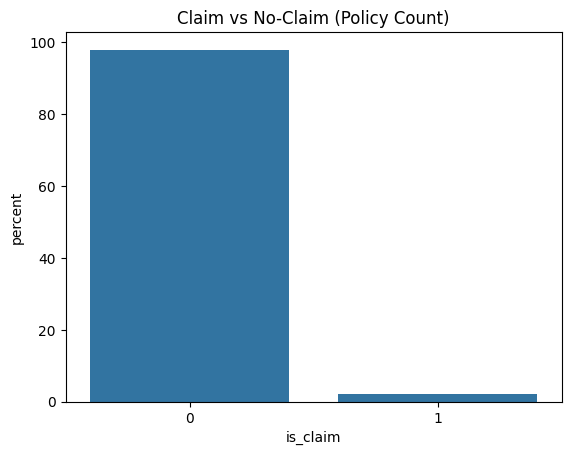

In [9]:
sns.countplot(x='is_claim', data=policy_df, stat='percent')
plt.title('Claim vs No-Claim (Policy Count)')

In [10]:
no_score_df.count()

contract_number         99937
premium                 99937
premium_wo_term         99937
operation_date          99937
claim_amount            99937
claim_cnt               99937
is_claim                99937
insurer_iin             99933
driver_iin              99937
is_individual_person    99937
is_residence            99937
region_id               99937
bonus_malus             99937
age_experience_id       99937
experience_year         99937
vehicle_type_id         99937
car_age                 99937
ownerkato_short         99937
model                   99930
car_number              99937
car_year                99855
engine_volume           99937
engine_power            99937
dtype: int64

In [11]:
for column in train_df.columns:
    if column.endswith('_name'):
        print(column + ":")
        pprint(list(train_df[column].unique()))
        print()

is_individual_person_name:
['Физ. лицо']

is_residence_name:
['Резидент', 'Не резидент']

region_name:
['01 Алматинская область',
 '18 Туркестанская область',
 '14 Мангистауская область',
 '17 Шымкент',
 '12 Кызылординская область',
 '05 Карагандинская область',
 '15 Алматы',
 '09 Жамбылская область',
 '07 Акмолинская область',
 '16 Астана',
 '13 Атырауская область',
 '10 Актюбинская область',
 '03 Восточно-Казахстанская область',
 '04 Костанайская область',
 '08 Павлодарская область',
 '11 Западно-Казахстанская область',
 '06 Северо-Казахстанская область',
 'Временная регистрация',
 'Временный въезд']

age_experience_name:
['старше 25 лет/стаж вождения более 2 лет',
 'старше 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения менее 2 лет',
 'менее 25 лет/стаж вождения более 2 лет']

vehicle_type_name:
['Легковые',
 'Прицепы(полуприцепы)',
 'Грузовые',
 'Мототранспорт',
 'Автобусы > 16 п.м.',
 'Автобусы до 16 п.м.']



In [12]:
marks = list(train_df['mark'].unique())
models = list(train_df['model'].unique())

print(len(marks), len(models))

537 4443


In [13]:
claims_by_car_age = train_df.groupby('car_age')['is_claim'].sum()
claims_by_car_age

car_age
до 7 лет включ.     366
свыше 7 лет        1590
Name: is_claim, dtype: int64

Text(0.5, 0, 'Год авто')

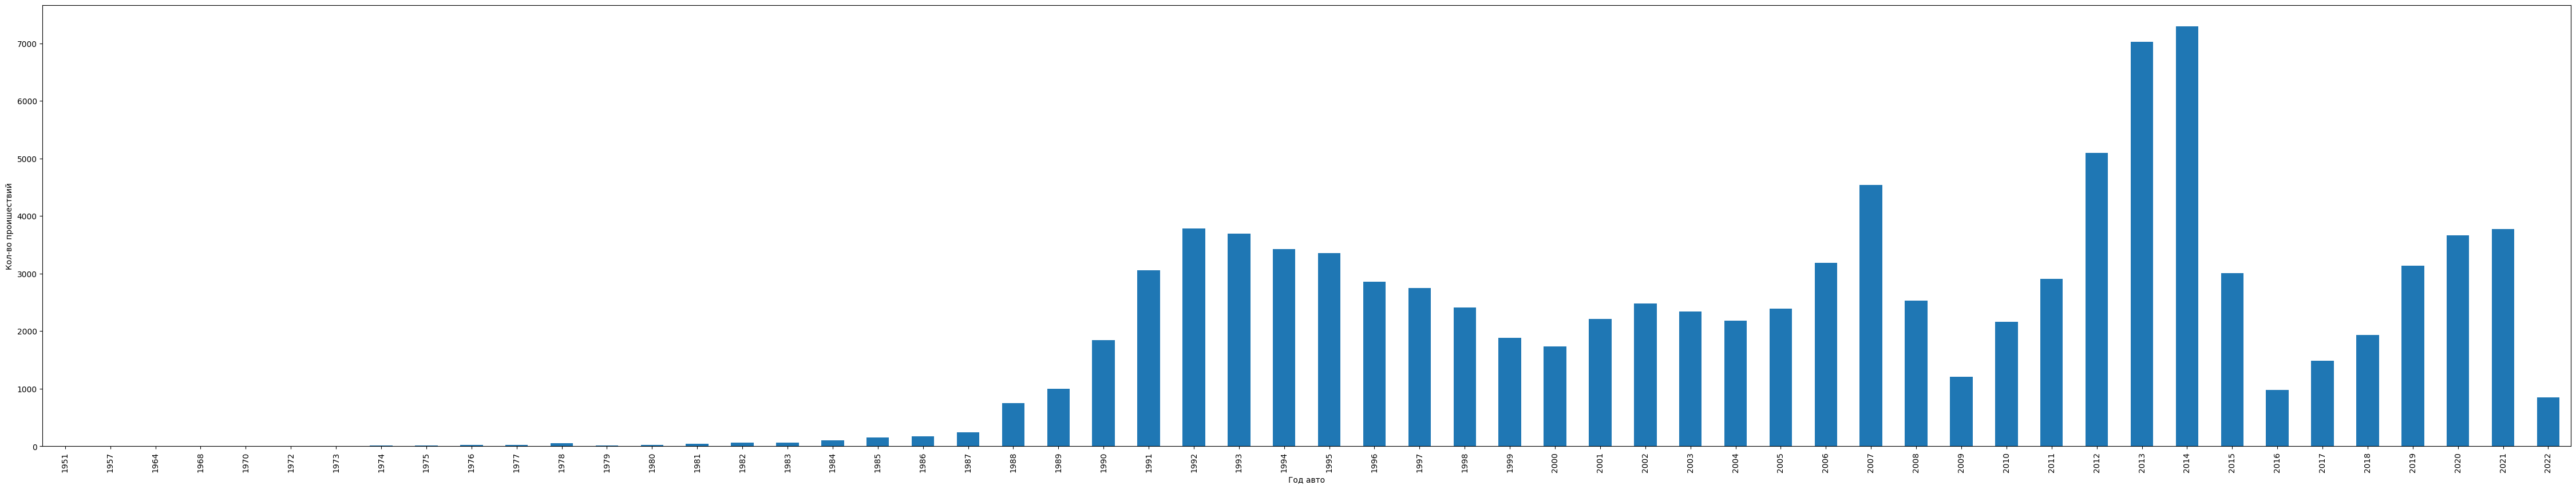

In [14]:
plt.figure(figsize=(57, 10))
train_df.groupby('car_year')['is_claim'].count().plot.bar()
plt.ylabel("Кол-во проишествий")
plt.xlabel("Год авто")

In [15]:
total_claims = train_df.groupby('mark')['is_claim'].sum()
stats = pd.concat([train_df['mark'].value_counts(), total_claims], axis=1)
stats.columns = ['total_cars', 'total_accidents']
stats['accident_rate'] = stats['total_accidents'] / stats['total_cars']
stats

,total_cars,total_accidents,accident_rate
mark,,,
TOYOTA,19437,384,0.019756
HYUNDAI,7241,135,0.018644
VOLKSWAGEN,6412,129,0.020119
MERCEDES-BENZ,5149,59,0.011459
LADA,5077,102,0.020091
...,...,...,...
CF650-2,1,0,0.000000
CA1010A1,1,0,0.000000
ПЛ,1,0,0.000000


In [16]:
train_df['accident_rate_by_mark'] = train_df['mark'].map(stats['accident_rate'])
train_df[['accident_rate_by_mark']].head()

/tmp/ipykernel_28490/4213722452.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['accident_rate_by_mark'] = train_df['mark'].map(stats['accident_rate'])


,accident_rate_by_mark
0,0.018644
1,0.020091
2,0.014778
3,0.019756
4,0.018606


In [17]:
train_df['coeff_of_claims'] = train_df['claim_amount'] / (train_df['premium_wo_term'] )
train_df['coeff_of_claims'] = train_df['coeff_of_claims'].replace([np.inf, -np.inf], np.nan)
train_df['coeff_of_claims'] = train_df['coeff_of_claims'].fillna(0)
train_df['claim_amount'] = train_df['claim_amount'].fillna(0)
train_df['claim_cnt'] = train_df['claim_cnt'].fillna(0)

train_df['coeff_of_claims'].describe()

/tmp/ipykernel_28490/3366629851.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['coeff_of_claims'] = train_df['claim_amount'] / (train_df['premium_wo_term'] )


count    100000.000000
mean          1.989600
std         114.894402
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       17924.913580
Name: coeff_of_claims, dtype: float64

In [18]:
BM_MAP = {
            13: 0.5, 
            12:0.55,
           11:0.6,
           10:0.65,
           9:0.7,
           8:0.75,
           7:0.8,
           6:0.85,
           5:0.90,
           4:0.95,
           3:1.0,
           2:1.4,
           1:1.55,
           0:2.3,
           -1:2.45}

train_df['bonus_malus_coeff'] = train_df['bonus_malus'].map(BM_MAP)
train_df[['bonus_malus_coeff']].head()

/tmp/ipykernel_28490/1989498409.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['bonus_malus_coeff'] = train_df['bonus_malus'].map(BM_MAP)


,bonus_malus_coeff
0,0.50
1,0.50
2,0.75
3,0.95
4,0.65


In [19]:
# Loss Ratio Calculation (Коэффициент выплат)
total_claims = policy_df['claim_amount'].sum()
total_premium = policy_df['premium_wo_term'].sum()
current_loss_ratio = (total_claims / total_premium) * 100 if total_premium != 0 else 0

print(f"\nCurrent Portfolio Loss Ratio: {current_loss_ratio:.2f}%")


Current Portfolio Loss Ratio: 127.79%
